In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

model = joblib.load(r'C:\Users\LENOVO\Downloads\upi-shield\models\xgboost_baseline.pkl')

df = pd.read_csv(r'C:\Users\LENOVO\Downloads\upi-shield\data\processed\featured_transactions.csv')

FEATURES = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'hour', 'day', 'is_weekend', 'type_encoded',
    'balance_diff_orig', 'balance_diff_dest',
    'orig_balance_zero', 'amount_deviation'
]

X = df[FEATURES]
y = df['isFraud']

print(f"Data loaded: {X.shape}")
print(f"Model loaded: {type(model)}")

C:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data loaded: (2770409, 13)
Model loaded: <class 'xgboost.sklearn.XGBClassifier'>


In [2]:

sample = X.sample(500, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer(sample)

print(f"SHAP values computed for {len(sample)} samples")
print(f"SHAP values shape: {shap_values.values.shape}")

SHAP values computed for 500 samples
SHAP values shape: (500, 13)


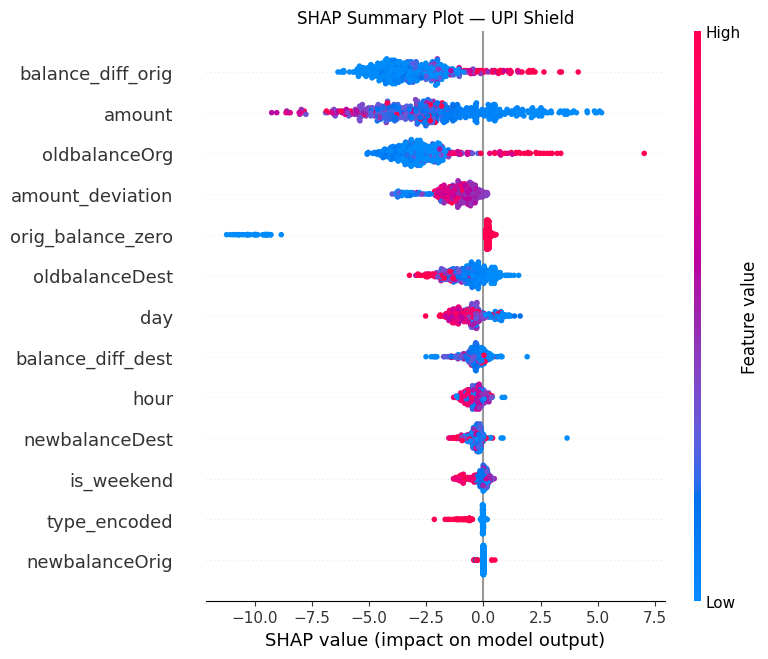

Saved.


In [3]:
import os
os.makedirs(r'C:\Users\LENOVO\Downloads\upi-shield\reports\figures', exist_ok=True)

# Summary plot — feature importance across all samples
plt.figure()
shap.summary_plot(shap_values, sample, feature_names=FEATURES, show=False)
plt.title("SHAP Summary Plot — UPI Shield")
plt.tight_layout()
plt.savefig(r'C:\Users\LENOVO\Downloads\upi-shield\reports\figures\day7_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

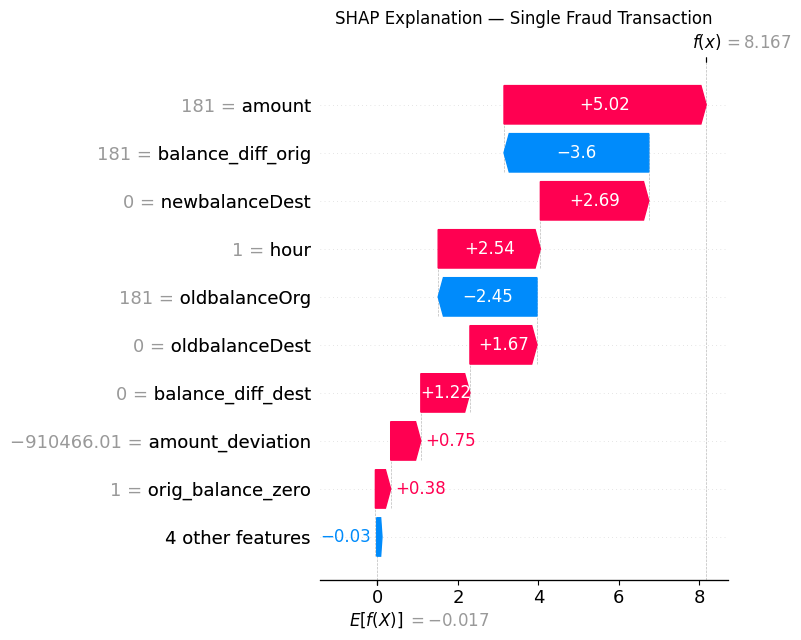

Saved.


In [4]:
# Pick one fraud transaction to explain
fraud_indices = df[df['isFraud'] == 1].index
fraud_sample = X.loc[fraud_indices].iloc[0:1]

# Compute SHAP for this single transaction
shap_single = explainer(fraud_sample)

# Waterfall plot
plt.figure()
shap.plots.waterfall(shap_single[0], show=False)
plt.title("SHAP Explanation — Single Fraud Transaction")
plt.tight_layout()
plt.savefig(r'C:\Users\LENOVO\Downloads\upi-shield\reports\figures\day7_shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

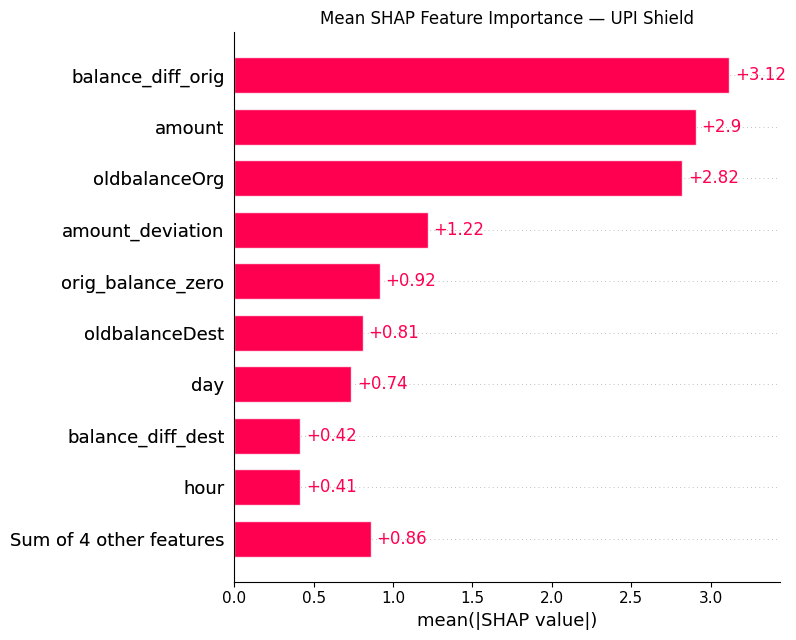

Saved.


In [5]:
plt.figure()
shap.plots.bar(shap_values, show=False)
plt.title("Mean SHAP Feature Importance — UPI Shield")
plt.tight_layout()
plt.savefig(r'C:\Users\LENOVO\Downloads\upi-shield\reports\figures\day7_shap_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")